# **Quantium Retail Analytics: Customer Purchasing Behaviour Analysis**
**Author:** Bélgica Reyes  
**Date:** May 2026  
**Role:** Data Analyst Intern (Virtual Experience)

---

## **Project Overview**
The goal of this analysis is to examine **transaction and customer data** to identify purchasing trends and behaviours within the "Chips" category. These insights will support a strategic recommendation for the upcoming category review with **Julia**, the Category Manager.

---

## **Key Objectives**
* **Data Cleaning & Validation:** Identify and remove outliers, correct data formats, and handle missing values.
* **Feature Engineering:** Extract **"Pack Size"** and **"Brand Name"** from product descriptions.
* **Customer Segmentation:** Analyze spend and purchase drivers across different life stages and premium segments.
* **Commercial Insights:** Provide a **data-driven strategy** to optimize the category's performance.

---

In [4]:
import pandas as pd
import os

# Updated file names based on your sidebar
file1 = 'QVI_transaction_data.xlsx'
file2 = 'QVI_purchase_behaviour.csv'

# Check and load
if os.path.exists(file1) and os.path.exists(file2):
    # Load Excel file
    df_trans = pd.read_excel(file1)
    # Load CSV file
    df_behavior = pd.read_csv(file2)

    print("Files loaded successfully!")
    print("\n--- Transactions Summary ---")
    display(df_trans.head())
    print("\n--- Purchase Behaviour Summary ---")
    display(df_behavior.head())
else:
    print("ERROR: One or more files not found.")
    print("Current files in Colab:", os.listdir())

Files loaded successfully!

--- Transactions Summary ---


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8



--- Purchase Behaviour Summary ---


,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


## **Phase 1: Data Cleaning & Initial Exploration**
In this section, we are addressing the technical issues identified in the initial data audit:
* **Date Conversion:** Transforming Excel's numeric date format into readable timestamps.
* **Outlier Detection:** Identifying unusually large transactions that might skew our analysis (e.g., commercial customers).
* **Data Integrity:** Checking for missing values (nulls) to ensure a complete dataset for Julia's review.

In [5]:
# 1. Convert DATE to a readable format
# Excel dates are numbers of days since Dec 30, 1899
df_trans['DATE'] = pd.to_datetime(df_trans['DATE'], unit='D', origin='1899-12-30')

# 2. Search for the massive outlier Zilinka mentioned
print("--- Checking for outliers in Quantity ---")
display(df_trans.sort_values(by='PROD_QTY', ascending=False).head())

# 3. Check for Nulls
print("\n--- Missing Values Summary ---")
print(df_trans.isnull().sum())

# 4. Summary statistics for numerical columns
print("\n--- Numerical Summary ---")
display(df_trans.describe())

--- Checking for outliers in Quantity ---


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.00
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.00
185113,2019-05-17,94,94214,93839,34,Pringles Slt Vingar 134g,5,18.50
185111,2019-05-18,94,94098,93080,114,Kettle Sensations Siracha Lime 150g,5,23.00
28147,2018-08-20,95,95297,95447,4,Dorito Corn Chp Supreme 380g,5,16.25



--- Missing Values Summary ---
DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

--- Numerical Summary ---


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,2018-12-30 00:52:12.879215616,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
min,2018-07-01 00:00:00,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,2019-06-30 00:00:00,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226


### **Addressing Outliers**
During the initial audit, we identified a significant outlier: **Customer ID 226000**.
This customer made two transactions of 200 packets of chips each. Since our goal is to analyze individual customer purchasing behavior for a retail category review, this commercial-scale activity is not representative of the typical shopper.

**Action:** We will investigate this customer further and remove them from the dataset to ensure our insights are not skewed.

In [6]:
# 1. Investigate the specific customer (226000)
# Let's see if they have any other transactions
customer_226000 = df_trans[df_trans['LYLTY_CARD_NBR'] == 226000]
print("--- Transactions for Customer 226000 ---")
display(customer_226000)

# 2. Filter out this customer from our main dataset
df_trans = df_trans[df_trans['LYLTY_CARD_NBR'] != 226000]

# 3. Verify they are gone
print(f"\nNew Max Quantity: {df_trans['PROD_QTY'].max()}")
print(f"Remaining transactions: {len(df_trans)}")

--- Transactions for Customer 226000 ---


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0



New Max Quantity: 5
Remaining transactions: 264834


## **Phase 2: Feature Engineering**
To perform a meaningful category review, we need to break down the product information:
* **Pack Size:** Extracting the numerical weight (grams) to see if customers prefer large party packs or small individual bags.
* **Brand Name:** Extracting the brand to identify which manufacturers are driving sales.

In [7]:
# 1. Extract Pack Size
# We look for digits (\d+) in the PROD_NAME
df_trans['PACK_SIZE'] = df_trans['PROD_NAME'].str.extract('(\d+)').astype(float)

# 2. Extract Brand Name
# We take the first word from PROD_NAME
df_trans['BRAND'] = df_trans['PROD_NAME'].str.split().str[0]

# 3. Quick check of the new columns
print("--- New Columns Created ---")
display(df_trans[['PROD_NAME', 'BRAND', 'PACK_SIZE']].head())

# 4. List all unique brands to check for duplicates or typos
print("\n--- Unique Brands Found ---")
print(sorted(df_trans['BRAND'].unique()))

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2646/826333946.py:3: SyntaxWarning: invalid escape sequence '\d'
  df_trans['PACK_SIZE'] = df_trans['PROD_NAME'].str.extract('(\d+)').astype(float)


--- New Columns Created ---


,PROD_NAME,BRAND,PACK_SIZE
0,Natural Chip Compny SeaSalt175g,Natural,175.0
1,CCs Nacho Cheese 175g,CCs,175.0
2,Smiths Crinkle Cut Chips Chicken 170g,Smiths,170.0
3,Smiths Chip Thinly S/Cream&Onion 175g,Smiths,175.0
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,Kettle,150.0



--- Unique Brands Found ---
['Burger', 'CCs', 'Cheetos', 'Cheezels', 'Cobs', 'Dorito', 'Doritos', 'French', 'Grain', 'GrnWves', 'Infuzions', 'Infzns', 'Kettle', 'NCC', 'Natural', 'Old', 'Pringles', 'RRD', 'Red', 'Smith', 'Smiths', 'Snbts', 'Sunbites', 'Thins', 'Tostitos', 'Twisties', 'Tyrrells', 'WW', 'Woolworths']


### **Brand Name Standardization**
Some brands appear under multiple names or abbreviations (e.g., 'Red' and 'RRD' for Red Rock Deli). To ensure our analysis accurately reflects brand performance, we are standardizing these names into single, consistent categories.

In [8]:
# Function to clean and standardize brand names
def clean_brands(brand):
    brand_map = {
        'Red': 'Red Rock Deli',
        'RRD': 'Red Rock Deli',
        'Natural': 'Natural Chip Co',
        'NCC': 'Natural Chip Co',
        'Infzns': 'Infuzions',
        'Smith': 'Smiths',
        'Snbts': 'Sunbites',
        'WW': 'Woolworths',
        'Dorito': 'Doritos',
        'GrnWves': 'Grain Waves',
        'Grain': 'Grain Waves'
    }
    return brand_map.get(brand, brand)

# Apply the cleaning function
df_trans['BRAND'] = df_trans['BRAND'].apply(clean_brands)

# Verify the clean brands
print("--- Standardized Brands ---")
print(sorted(df_trans['BRAND'].unique()))

--- Standardized Brands ---
['Burger', 'CCs', 'Cheetos', 'Cheezels', 'Cobs', 'Doritos', 'French', 'Grain Waves', 'Infuzions', 'Kettle', 'Natural Chip Co', 'Old', 'Pringles', 'Red Rock Deli', 'Smiths', 'Sunbites', 'Thins', 'Tostitos', 'Twisties', 'Tyrrells', 'Woolworths']


## **Phase 3: Data Integration**
To analyze how different customer segments behave, we are merging our cleaned transaction data with the customer behavior dataset. This creates a single "Master Dataset" where every purchase is linked to a specific customer's Life Stage and Premium Segment.

In [9]:
# Merging the datasets using the unique Loyalty Card Number
# We use an 'inner' join to ensure we only analyze customers for whom we have both transaction and demographic data
data = pd.merge(df_trans, df_behavior, on='LYLTY_CARD_NBR', how='inner')

# Check the results
print(f"Master Dataset Shape: {data.shape}")
print("\n--- Final Master Data Preview ---")
display(data.head())

# One final check: Did we lose any data during the merge?
if len(data) < len(df_trans):
    print(f"\nNote: {len(df_trans) - len(data)} transactions were removed because the customer IDs were not found in the behavior dataset.")

Master Dataset Shape: (264834, 12)

--- Final Master Data Preview ---


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0,Natural Chip Co,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175.0,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150.0,Kettle,MIDAGE SINGLES/COUPLES,Budget


## **Phase 4: Data Analysis & Strategic Insights**
In this section, we analyze the drivers of sales. We focus on:
* **Total Sales by Segment:** Identifying which customer groups contribute most to revenue.
* **Customer Proportions:** Understanding if high sales come from many customers or high-spending individuals.
* **Brand Preferences:** Checking if certain segments have a "signature" brand.

<Figure size 1200x700 with 0 Axes>

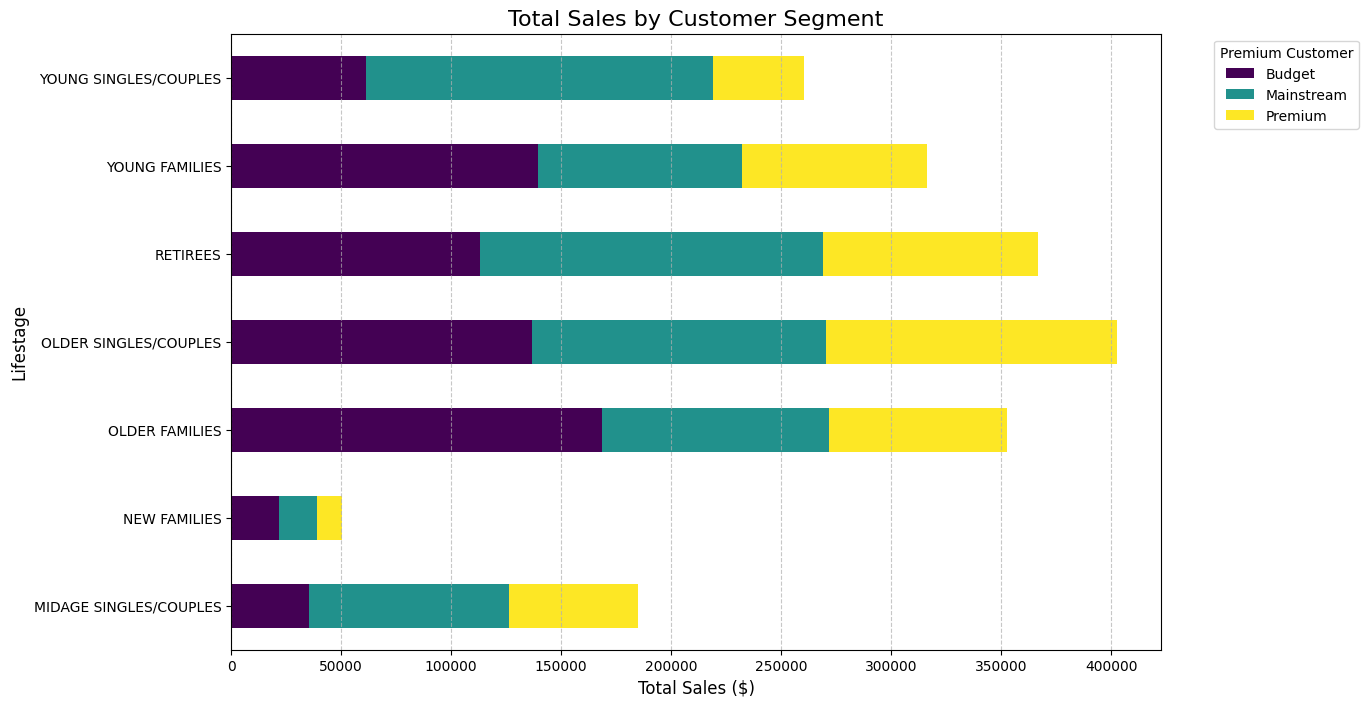

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Total Sales by Lifestage and Premium Segment
sales_summary = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().unstack()

# Plotting
plt.figure(figsize=(12, 7))
sales_summary.plot(kind='barh', stacked=True, figsize=(12, 8), colormap='viridis')

plt.title('Total Sales by Customer Segment', fontsize=16)
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Lifestage', fontsize=12)
plt.legend(title='Premium Customer', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

### **Deep Dive: What drives sales?**
To understand the "why" behind the sales, we need to determine if high revenue is driven by a high number of customers or by customers spending more per transaction. We will also examine brand and pack size preferences for top-performing segments.

<Figure size 1200x700 with 0 Axes>

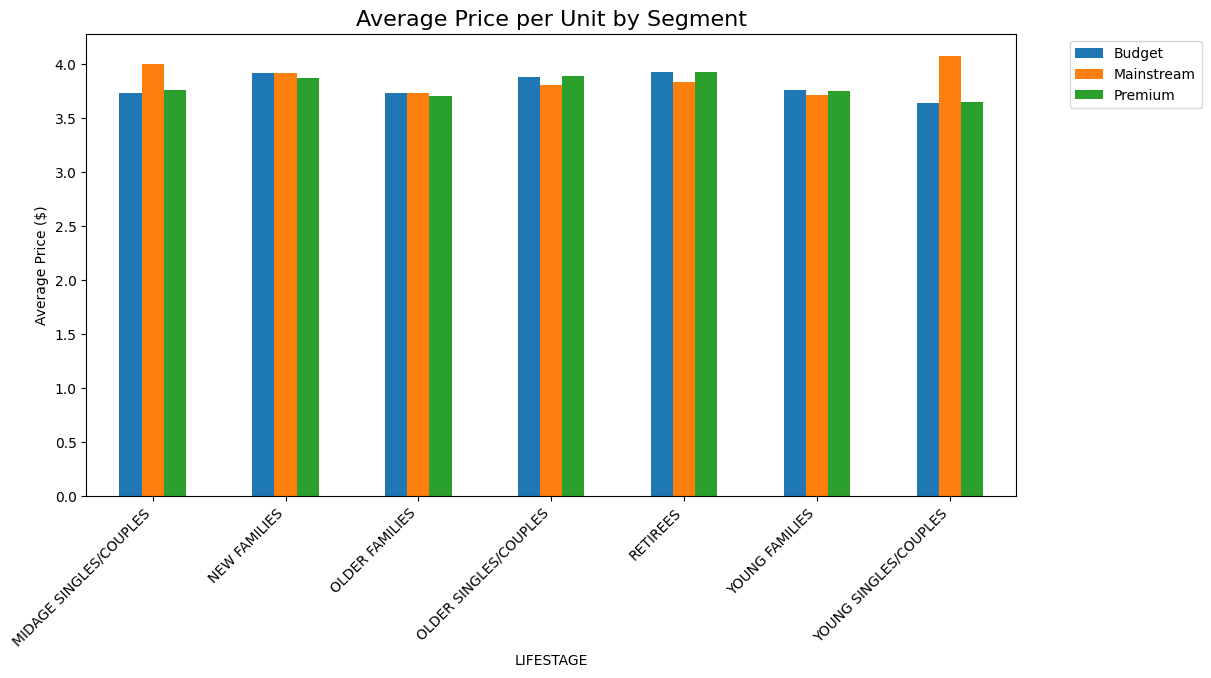

In [11]:
# 1. Average price per unit by segment
# (Total Sales / Total Quantity)
data['PRICE_PER_UNIT'] = data['TOT_SALES'] / data['PROD_QTY']

avg_price = data.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['PRICE_PER_UNIT'].mean().unstack()

# Plotting Average Price
plt.figure(figsize=(12, 7))
avg_price.plot(kind='bar', figsize=(12, 6))
plt.title('Average Price per Unit by Segment', fontsize=16)
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### **Brand Preference Deep Dive**
We have identified that Mainstream Young Singles/Couples are willing to pay more per unit. Now, we will examine their brand preferences to see if they gravitate toward specific brands like Kettle or Pringles compared to the rest of the population.

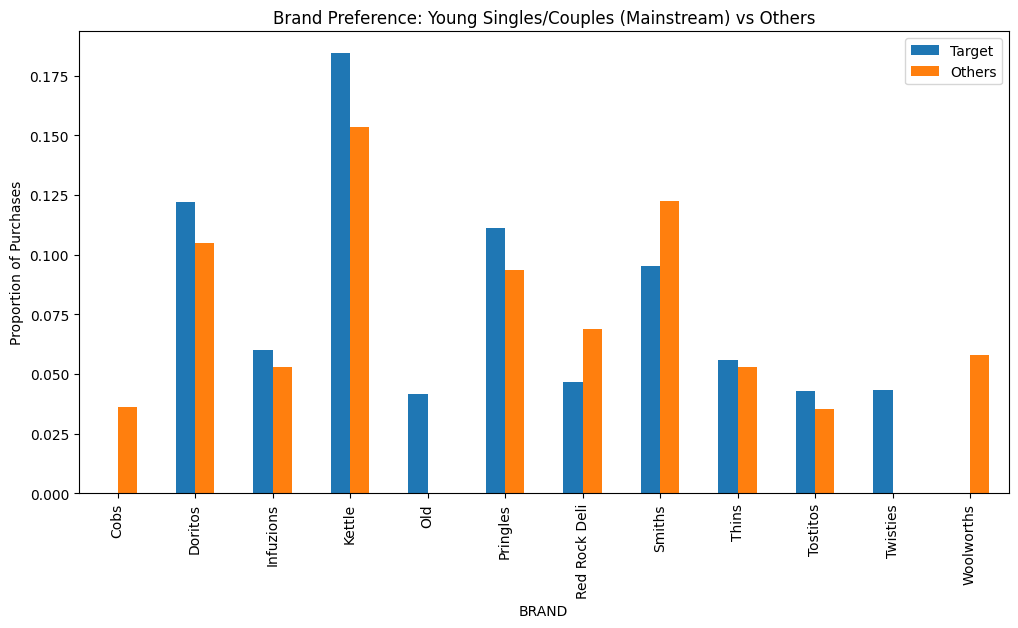

In [12]:
# 1. Focus on Mainstream Young Singles/Couples
target_segment = data[(data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & (data['PREMIUM_CUSTOMER'] == 'Mainstream')]
other_segments = data[~((data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') & (data['PREMIUM_CUSTOMER'] == 'Mainstream'))]

# 2. Compare Brand Affinity
target_brand = target_segment['BRAND'].value_counts(normalize=True).head(10)
other_brand = other_segments['BRAND'].value_counts(normalize=True).head(10)

# Combine for comparison
brand_comparison = pd.DataFrame({'Target': target_brand, 'Others': other_brand})
brand_comparison.plot(kind='bar', figsize=(12,6))
plt.title('Brand Preference: Young Singles/Couples (Mainstream) vs Others')
plt.ylabel('Proportion of Purchases')
plt.show()

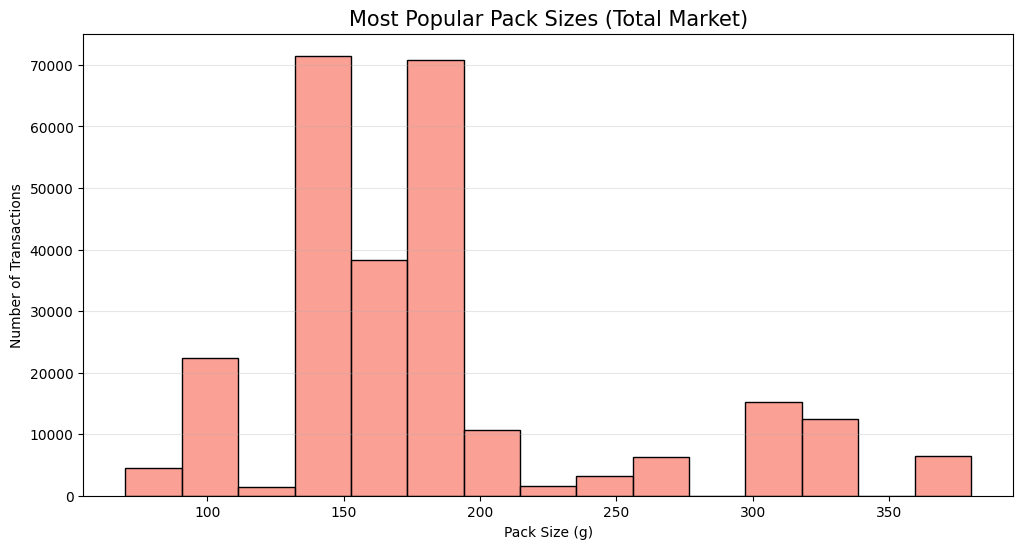

--- Top 5 Pack Sizes for Mainstream Young Singles/Couples ---
PACK_SIZE
175.0    0.239618
150.0    0.155414
134.0    0.111010
110.0    0.098350
170.0    0.075525
Name: proportion, dtype: float64


In [13]:
# 1. Plot the distribution of pack sizes for the whole dataset
plt.figure(figsize=(12, 6))
sns.histplot(data['PACK_SIZE'], bins=15, kde=False, color='salmon')
plt.title('Most Popular Pack Sizes (Total Market)', fontsize=15)
plt.xlabel('Pack Size (g)')
plt.ylabel('Number of Transactions')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 2. Check the specific preference of our Target Segment
target_pack = target_segment['PACK_SIZE'].value_counts(normalize=True).head(5)
print("--- Top 5 Pack Sizes for Mainstream Young Singles/Couples ---")
print(target_pack)

# **Final Executive Summary & Recommendations**

## **Key Insights**
1. **High-Value Segment:** While 'Mainstream Young Singles/Couples' are not the largest segment in total volume, they exhibit the **highest average price per unit ($4.00+)**. They are willing to pay a premium for quality over quantity.
2. **Brand Affinity:** This segment shows a significantly higher preference for **Kettle** and **Pringles** compared to other customer groups. They tend to avoid budget-tier or store brands (Woolworths).
3. **Pack Size Optimization:** Their preferred pack size is **175g**, followed by 150g. Larger "Family Packs" (380g) do not resonate as strongly with this demographic.

## **Strategic Recommendations for Julia**
* **Premium Placement:** Increase shelf space for Kettle and Pringles in stores located near universities or high-density urban areas.
* **Pricing Strategy:** Avoid aggressive discounting for the 175g range in the Mainstream segment. These customers are driven by brand loyalty and flavor variety rather than price.
* **Bundle Promotions:** Consider "Meal Deal" bundles (e.g., a 175g bag of Kettle chips with a premium beverage) to capitalize on their higher spending capacity per visit.